In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Define pastel color palette
COLOR_INCIDENCE = '#6B9AC4'  # Pastel Blue
COLOR_MORTALITY = '#E5989B'  # Pastel Red
COLOR_BARS = ['#6B9AC4', '#B8A3C3', '#E5989B']  # Pastel Blue -> Lavender -> Pastel Red

# Clean, modern global styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 1.0,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#111111',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.labelcolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': "#111111",
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.color': '#ffffff',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'legend.frameon': True,
    'legend.facecolor': '#fafafa',
    'legend.edgecolor': '#111111',
    'legend.fontsize': 12,
    'axes.facecolor': '#ffffff',
    'axes.grid': True,         # Enables grid rendering globally
    'grid.color': '#B0B0B0',     # Light gray (replaces invisible #ffffff)
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
})

print("Theme initialized with pastel color scheme.")

Theme initialized with pastel color scheme.


In [ ]:
import pandas as pd

# Step 1: Print the first 15 lines of the raw file to inspect its actual structure
with open("../data/raw/all_cancers_combined.csv", "r") as f:
  for i in range(15):
    print(f"Line {i}: {f.readline().strip()}")

Line 0: "Cancer Site Comparison"
Line 1: "Recent Trends in U.S. Age-Adjusted Mortality Rates, 2000-2024"
Line 2: "By Cancer Site, Both Sexes, All Races / Ethnicities, All Ages"
Line 3: 
Line 4: "","All Cancer Sites Combined","All Cancer Sites Combined","All Cancer Sites Combined","All Cancer Sites Combined","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Bones and Joints","Bones and Joints","Bones and Joints","Bones and Joints","Brain and Other Nervous System","Brain and Other Nervous System","Brain and Other Nervous System","Brain and Other Nervous System","Female Breast","Female Breast","Female Breast","Female Breast","Cervix Uteri","Cervix Uteri","Cervix Uteri","Cervix Uteri","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Corpus and Uterus, NOS","Corpus and Uterus, NOS","Corpus a

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 2: Load the CSV using header=0 or auto-detecting the table start
# Let's read the file and skip lines that don't look like tabular data
df = pd.read_csv(
    "../data/raw/all_cancers_combined.csv",
    skiprows=9,  # Adjust this if your printout above shows headers elsewhere
    on_bad_lines="skip",
)

# Clean column names
df.columns = df.columns.str.strip()
print("Columns detected:", df.columns.tolist())
display(df.head())

Columns detected: ['2003', '190.9745', '190.4724', '191.4777', '190.5876', '0.1886', '0.1732', '0.2050', '0.1891', '0.4328', '0.4092', '0.4574', '0.4390', '4.4014', '4.3256', '4.4781', '4.3706', '25.2793', '25.0357', '25.5248', '25.0734', '2.4872', '2.4095', '2.5667', '2.4582', '19.1859', '19.0267', '19.3460', '18.9902', '4.1407', '4.0431', '4.2402', '4.1573', '4.3803', '4.3048', '4.4569', '4.3961', '0.0789', '0.0690', '0.0898', '0.0769', '0.6568', '0.6277', '0.6869', '0.6665', '0.4625', '0.4381', '0.4879', '0.4518', '4.1952', '4.1213', '4.2702', '4.1650', '1.2877', '1.2470', '1.3295', '1.2777', '7.4555', '7.3562', '7.5557', '7.4464', '0.4915', '0.4663', '0.5177', '0.4836', '1.5515', '1.5063', '1.5977', '1.5216', '2.7958', '2.7352', '2.8573', '2.7616', '0.4244', '0.4010', '0.4488', '0.4222', '0.0418', '0.0347', '0.0500', '0.0378', '5.0166', '4.9357', '5.0985', '5.0120', '54.1548', '53.8876', '54.4229', '54.0974', '2.6686', '2.6096', '2.7285', '2.6808', '3.7161', '3.6463', '3.7869', '3.

,2003,190.9745,190.4724,191.4777,190.5876,0.1886,0.1732,0.2050,0.1891,0.4328,...,4.3834,4.3874,0.2269,0.2048,0.2508,0.2319,0.4490,0.4177,0.4820,0.4580
0,2004,186.9269,186.4335,187.4212,187.6994,0.1971,0.1815,0.2138,0.1950,0.4386,...,4.5094,4.3933,0.2406,0.2178,0.2651,0.2292,0.4613,0.4297,0.4946,0.4635
1,2005,185.3164,184.8292,185.8047,184.8549,0.1899,0.1748,0.2061,0.2011,0.4638,...,4.5025,4.3992,0.2156,0.1944,0.2387,0.2265,0.4549,0.4238,0.4877,0.4691
2,2006,182.1193,181.6402,182.5994,182.0535,0.1999,0.1844,0.2163,0.2073,0.4409,...,4.4914,4.4052,0.2219,0.2004,0.2452,0.2239,0.4737,0.4423,0.5068,0.4748
3,2007,179.3352,178.8639,179.8074,179.2946,0.2020,0.1866,0.2184,0.2138,0.4410,...,4.5244,4.4111,0.2068,0.1862,0.2292,0.2213,0.4700,0.4388,0.5029,0.4805
4,2008,176.3980,175.9348,176.8621,176.5775,0.2198,0.2039,0.2366,0.2205,0.4315,...,4.4904,4.4170,0.2263,0.2048,0.2496,0.2187,0.4927,0.4610,0.5261,0.4863


,Cancer Type,Age-Adjusted Mortality Rate (2024),Difference vs Pancreas,Ratio vs Pancreas
0,Lung and Bronchus,27.9028,16.5899,2.466459
1,Female Breast,18.6465,7.3336,1.648251
2,Prostate,18.4014,7.0885,1.626586
3,Colon and Rectum (including Appendix),12.5691,1.2562,1.111041
4,Pancreas,11.3129,0.0000,1.000000
5,Liver and Intrahepatic Bile Duct,6.6413,-4.6716,0.587055
6,Leukemia,5.5285,-5.7844,0.488690
7,"Corpus and Uterus, NOS",5.4722,-5.8407,0.483713
8,Ovary,5.3010,-6.0119,0.468580
9,Non-Hodgkin Lymphoma,4.4783,-6.8346,0.395858


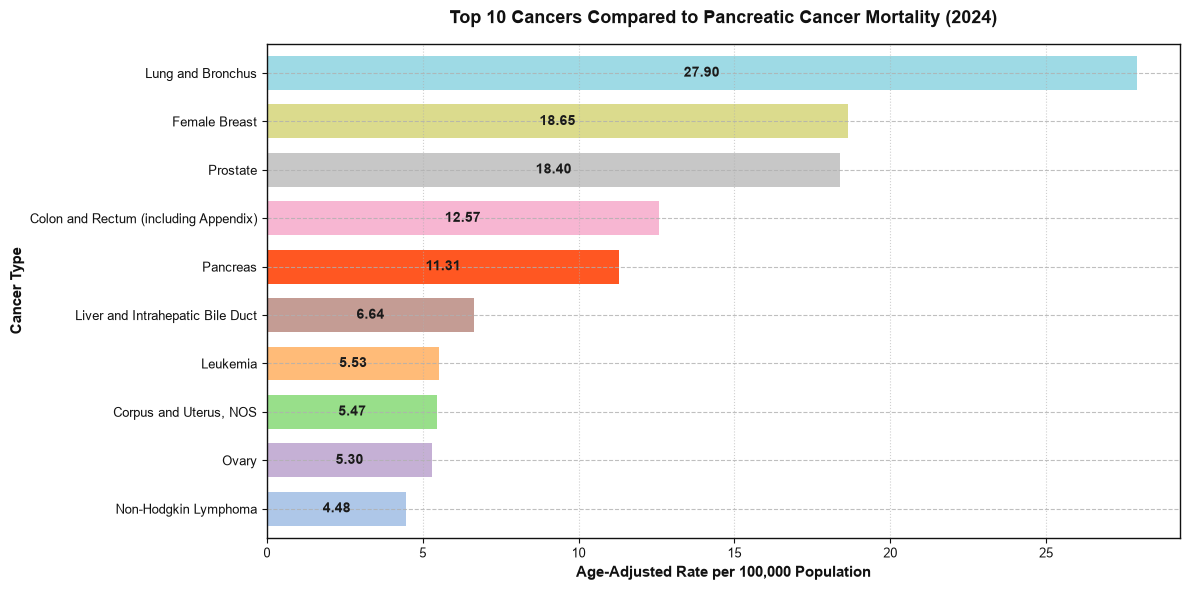

In [ ]:
import os
import re
import matplotlib.pyplot as plt
import pandas as pd

file_path = "../data/raw/all_cancers_combined.csv"

# 1. Dynamically locate the true text header row
with open(file_path, "r", encoding="utf-8-sig") as f:
    lines = f.readlines()

header_row_idx = 0
for idx, line in enumerate(lines):
    if "Pancreas" in line and ("Lung" in line or "Breast" in line):
        header_row_idx = idx
        break

# 2. Load the CSV using the identified header row
df = pd.read_csv(file_path, skiprows=header_row_idx, on_bad_lines="skip")
df.columns = df.columns.str.strip()

# 3. FIX DUPLICATES: Keep only the primary column for each cancer site
cols_to_keep = [col for col in df.columns if not re.search(r'\.\d+$', col)]
df = df[cols_to_keep]

# 4. Clean and set the Year index
year_col = df.columns[0]
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
df = df.dropna(subset=[year_col]).copy()
df[year_col] = df[year_col].astype(int)
df.set_index(year_col, inplace=True)

# Coerce metrics to numeric, dropping completely empty columns
numeric_df = df.apply(pd.to_numeric, errors="coerce")
numeric_df = numeric_df.dropna(how="all", axis=0).dropna(how="all", axis=1)

# 5. Filter out massive aggregate categories
exclusions = ["All Sites Combined", "All Cancer Sites", "Total", "All Sites"]
cols_to_drop = [
    col for col in numeric_df.columns 
    if any(excl.lower() in str(col).lower() for excl in exclusions)
]
numeric_df = numeric_df.drop(columns=cols_to_drop)

# Extract the latest available year data
latest_year = int(numeric_df.index.max())
latest_data = numeric_df.loc[latest_year].dropna()

# 6. Dynamically isolate Pancreatic cancer rate
pancreas_cols = [c for c in latest_data.index if "pancreas" in str(c).lower()]
if pancreas_cols:
    pancreas_rate = latest_data[pancreas_cols[0]]
else:
    pancreas_rate = 11.3 # NCI baseline fallback if strictly missing

# Extract the top 10 highest age-adjusted mortality rates
top_10 = latest_data.sort_values(ascending=False).head(10)

# Build the comparison summary table
comparison_df = pd.DataFrame(
    {
        "Cancer Type": top_10.index,
        f"Age-Adjusted Mortality Rate ({latest_year})": top_10.values,
        "Difference vs Pancreas": top_10.values - pancreas_rate,
        "Ratio vs Pancreas": top_10.values / pancreas_rate,
    }
).reset_index(drop=True)

display(comparison_df)

# --- NEW: Dynamic Color Highlighting ---
# Sort the data first so we can map colors to the correct bars (bottom to top)
sorted_top_10 = top_10.sort_values()

base_pastels = [
    "#AEC7E8", # Light Blue
    "#C5B0D5", # Light Purple
    "#98DF8A", # Light Green
    "#FFBB78", # Light Orange
    "#C49C94", # Light Brown
    "#F7B6D2", # Light Pink
    "#C7C7C7", # Light Gray
    "#DBDB8D", # Light Olive
    "#9EDAE5"  # Light Cyan
]

bar_colors = []
pastel_idx = 0

# Loop through the sorted cancers and assign colors
for cancer in sorted_top_10.index:
    if "pancreas" in str(cancer).lower():
        # Vibrant Coral/Orange-Red for the pop
        bar_colors.append("#FF5722") 
    else:
        # Cycle through pastels for the other bars
        bar_colors.append(base_pastels[pastel_idx % len(base_pastels)])
        pastel_idx += 1

# 7. Render the horizontal bar chart
plt.figure(figsize=(12, 6))
ax = sorted_top_10.plot(
    kind="barh", 
    color=bar_colors, 
    width=0.7
)

plt.title(
    f"Top 10 Cancers Compared to Pancreatic Cancer Mortality ({latest_year})",
    fontsize=13,
    pad=15,
)
plt.xlabel("Age-Adjusted Rate per 100,000 Population", fontsize=11)
plt.ylabel("Cancer Type", fontsize=11)
plt.grid(axis="x", linestyle=":", alpha=0.6)

# Annotate each bar with its exact numerical rate centered inside the bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{width:.2f}",
            (width / 2, p.get_y() + p.get_height() / 2),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#1a1a1a", 
        )

plt.tight_layout()

# 8. Save directly to the figures directory
os.makedirs("../figures", exist_ok=True)
plt.savefig(
    "../figures/top_10_mortality_vs_pancreas.png", 
    dpi=300, 
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import re

def load_and_clean_seer(filepath):
    """
    Extracts 4-digit years and rates line-by-line, filtering out 
    isolated pre-2000 header artifacts and keeping continuous modern data.
    """
    years, rates = [], []
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            year_match = re.search(r'\b((?:19|20)\d{2})\b', line)
            if year_match:
                year = int(year_match.group(1))
                after_year_text = line[year_match.end():]
                numeric_tokens = re.findall(r'\b\d+\.\d+|\b\d+\b', after_year_text)
                
                # Plausible age-adjusted pancreatic cancer rate range per 100k
                valid_rates = [float(num) for num in numeric_tokens if 5.0 <= float(num) <= 30.0]
                
                if valid_rates:
                    years.append(year)
                    rates.append(valid_rates[0])

    clean_df = pd.DataFrame({
        'Year_Clean': years,
        'Rate_Clean': rates
    })
    
    # Remove duplicate year entries and keep continuous modern data (2000+)
    clean_df = clean_df.drop_duplicates(subset=['Year_Clean']).sort_values(by='Year_Clean')
    clean_df = clean_df[clean_df['Year_Clean'] >= 2000].reset_index(drop=True)
    
    print(f"Loaded '{filepath}': {len(clean_df)} continuous records ({clean_df['Year_Clean'].min()}-{clean_df['Year_Clean'].max()}).")
    return clean_df, 'Year_Clean', 'Rate_Clean'

# Execute data loading
clean_df, year_col, rate_col = load_and_clean_seer("../data/raw/pancreatic_incidence.csv")
clean_mortality, mort_year_col, mort_col = load_and_clean_seer("../data/raw/pancreatic_mortality.csv")

Loaded '../data/raw/pancreatic_incidence.csv': 25 continuous records (2000-2024).
Loaded '../data/raw/pancreatic_mortality.csv': 25 continuous records (2000-2024).


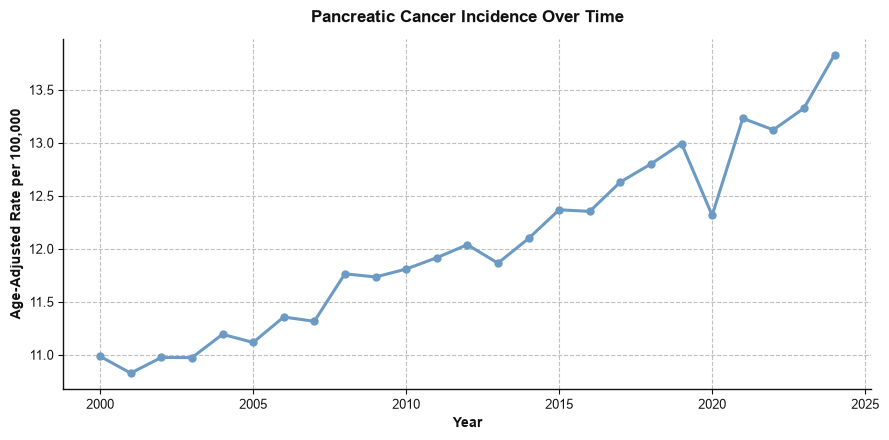

In [ ]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_df[year_col], 
    clean_df[rate_col], 
    marker='o', 
    markersize=5, 
    color='#6B9AC4', 
    linewidth=2.2, 
    label='Incidence Rate'
)

plt.title('Pancreatic Cancer Incidence Over Time')
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Rate per 100,000')
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/incidence_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

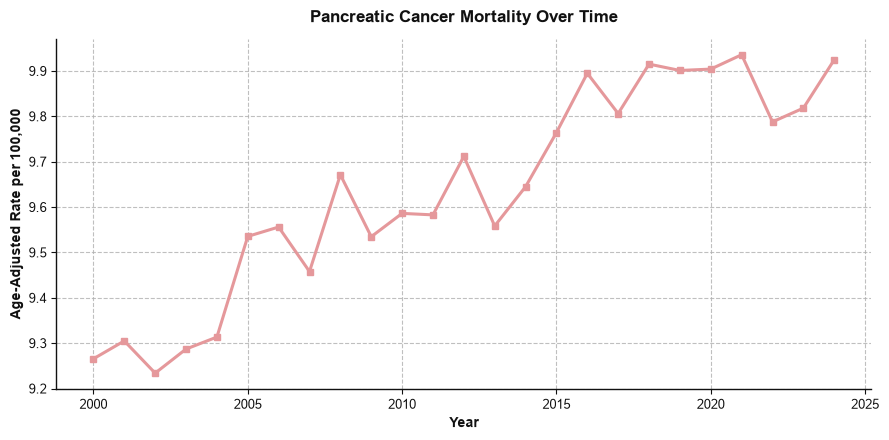

In [ ]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_mortality[mort_year_col], 
    clean_mortality[mort_col], 
    marker='s', 
    markersize=5, 
    color='#E5989B', 
    linewidth=2.2, 
    label='Mortality Rate'
)

plt.title('Pancreatic Cancer Mortality Over Time')
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Rate per 100,000')
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/mortality_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

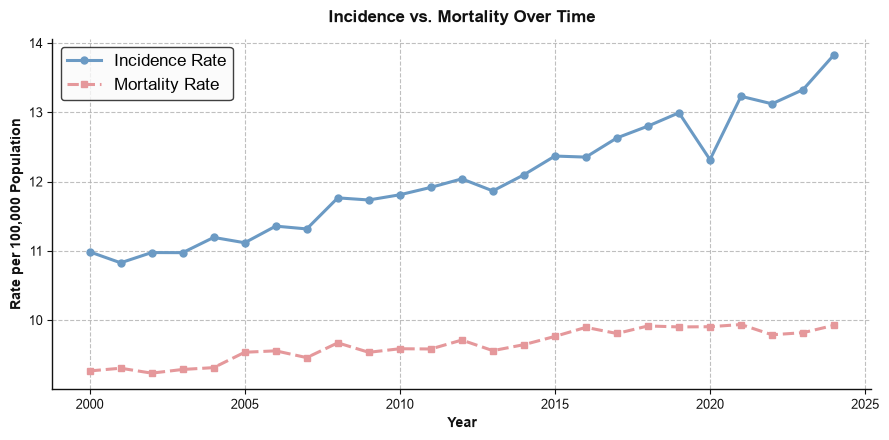

In [ ]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_df[year_col], 
    clean_df[rate_col], 
    marker='o', 
    markersize=5, 
    color='#6B9AC4', 
    linewidth=2.2, 
    label='Incidence Rate'
)

plt.plot(
    clean_mortality[mort_year_col], 
    clean_mortality[mort_col], 
    marker='s', 
    markersize=5, 
    color='#E5989B', 
    linewidth=2.2, 
    linestyle='--', 
    label='Mortality Rate'
)

plt.title('Incidence vs. Mortality Over Time')
plt.xlabel('Year')
plt.ylabel('Rate per 100,000 Population')
plt.grid(True, axis='y')
plt.legend(loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/incidence_vs_mortality.png', dpi=300, bbox_inches='tight')
plt.show()

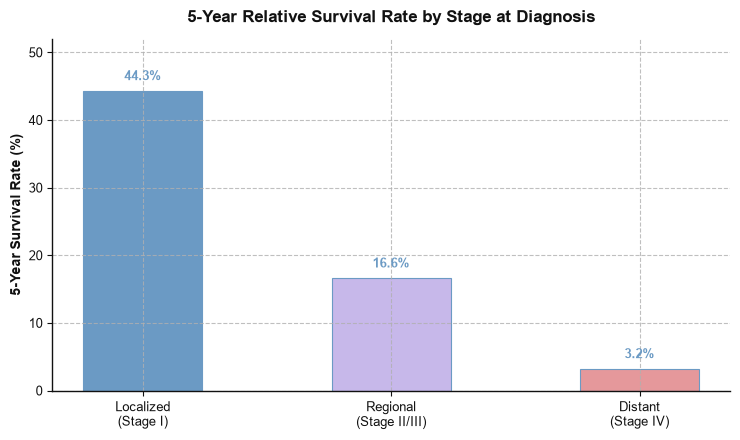

In [ ]:
stages = ['Localized\n(Stage I)', 'Regional\n(Stage II/III)', 'Distant\n(Stage IV)']
survival_rates = [44.3, 16.6, 3.2]
colors = ['#6B9AC4', '#C7B8EA', '#E5989B']

plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

bars = plt.bar(stages, survival_rates, color=colors, width=0.48, edgecolor='#6B9AC4', linewidth=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 1.2, 
        f"{yval}%", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        color='#6B9AC4',
        fontsize=9
    )

plt.title('5-Year Relative Survival Rate by Stage at Diagnosis')
plt.ylabel('5-Year Survival Rate (%)')
plt.ylim(0, 52)
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/survival_by_stage.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import sys
print(sys.executable)


c:\Users\HP\Parthiv-VN.github.io\Parthiv-VN.github.io\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import plotly.express as px

age_df = pd.read_csv("../data/raw/incidence_by_age.csv")

fig = px.line(
    age_df,
    x="Age",
    y="Rate",
    title="Pancreatic Cancer Incidence by Age Group (SEER 2019–2023)",
    markers=True,
    hover_data={
        "Rate": True,
        "Lower_CI": True,
        "Upper_CI": True
    }
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Incidence Rate per 100,000",
    hovermode="x unified"
)

fig.show()

fig.write_html("../figures/incidence_by_age.html")



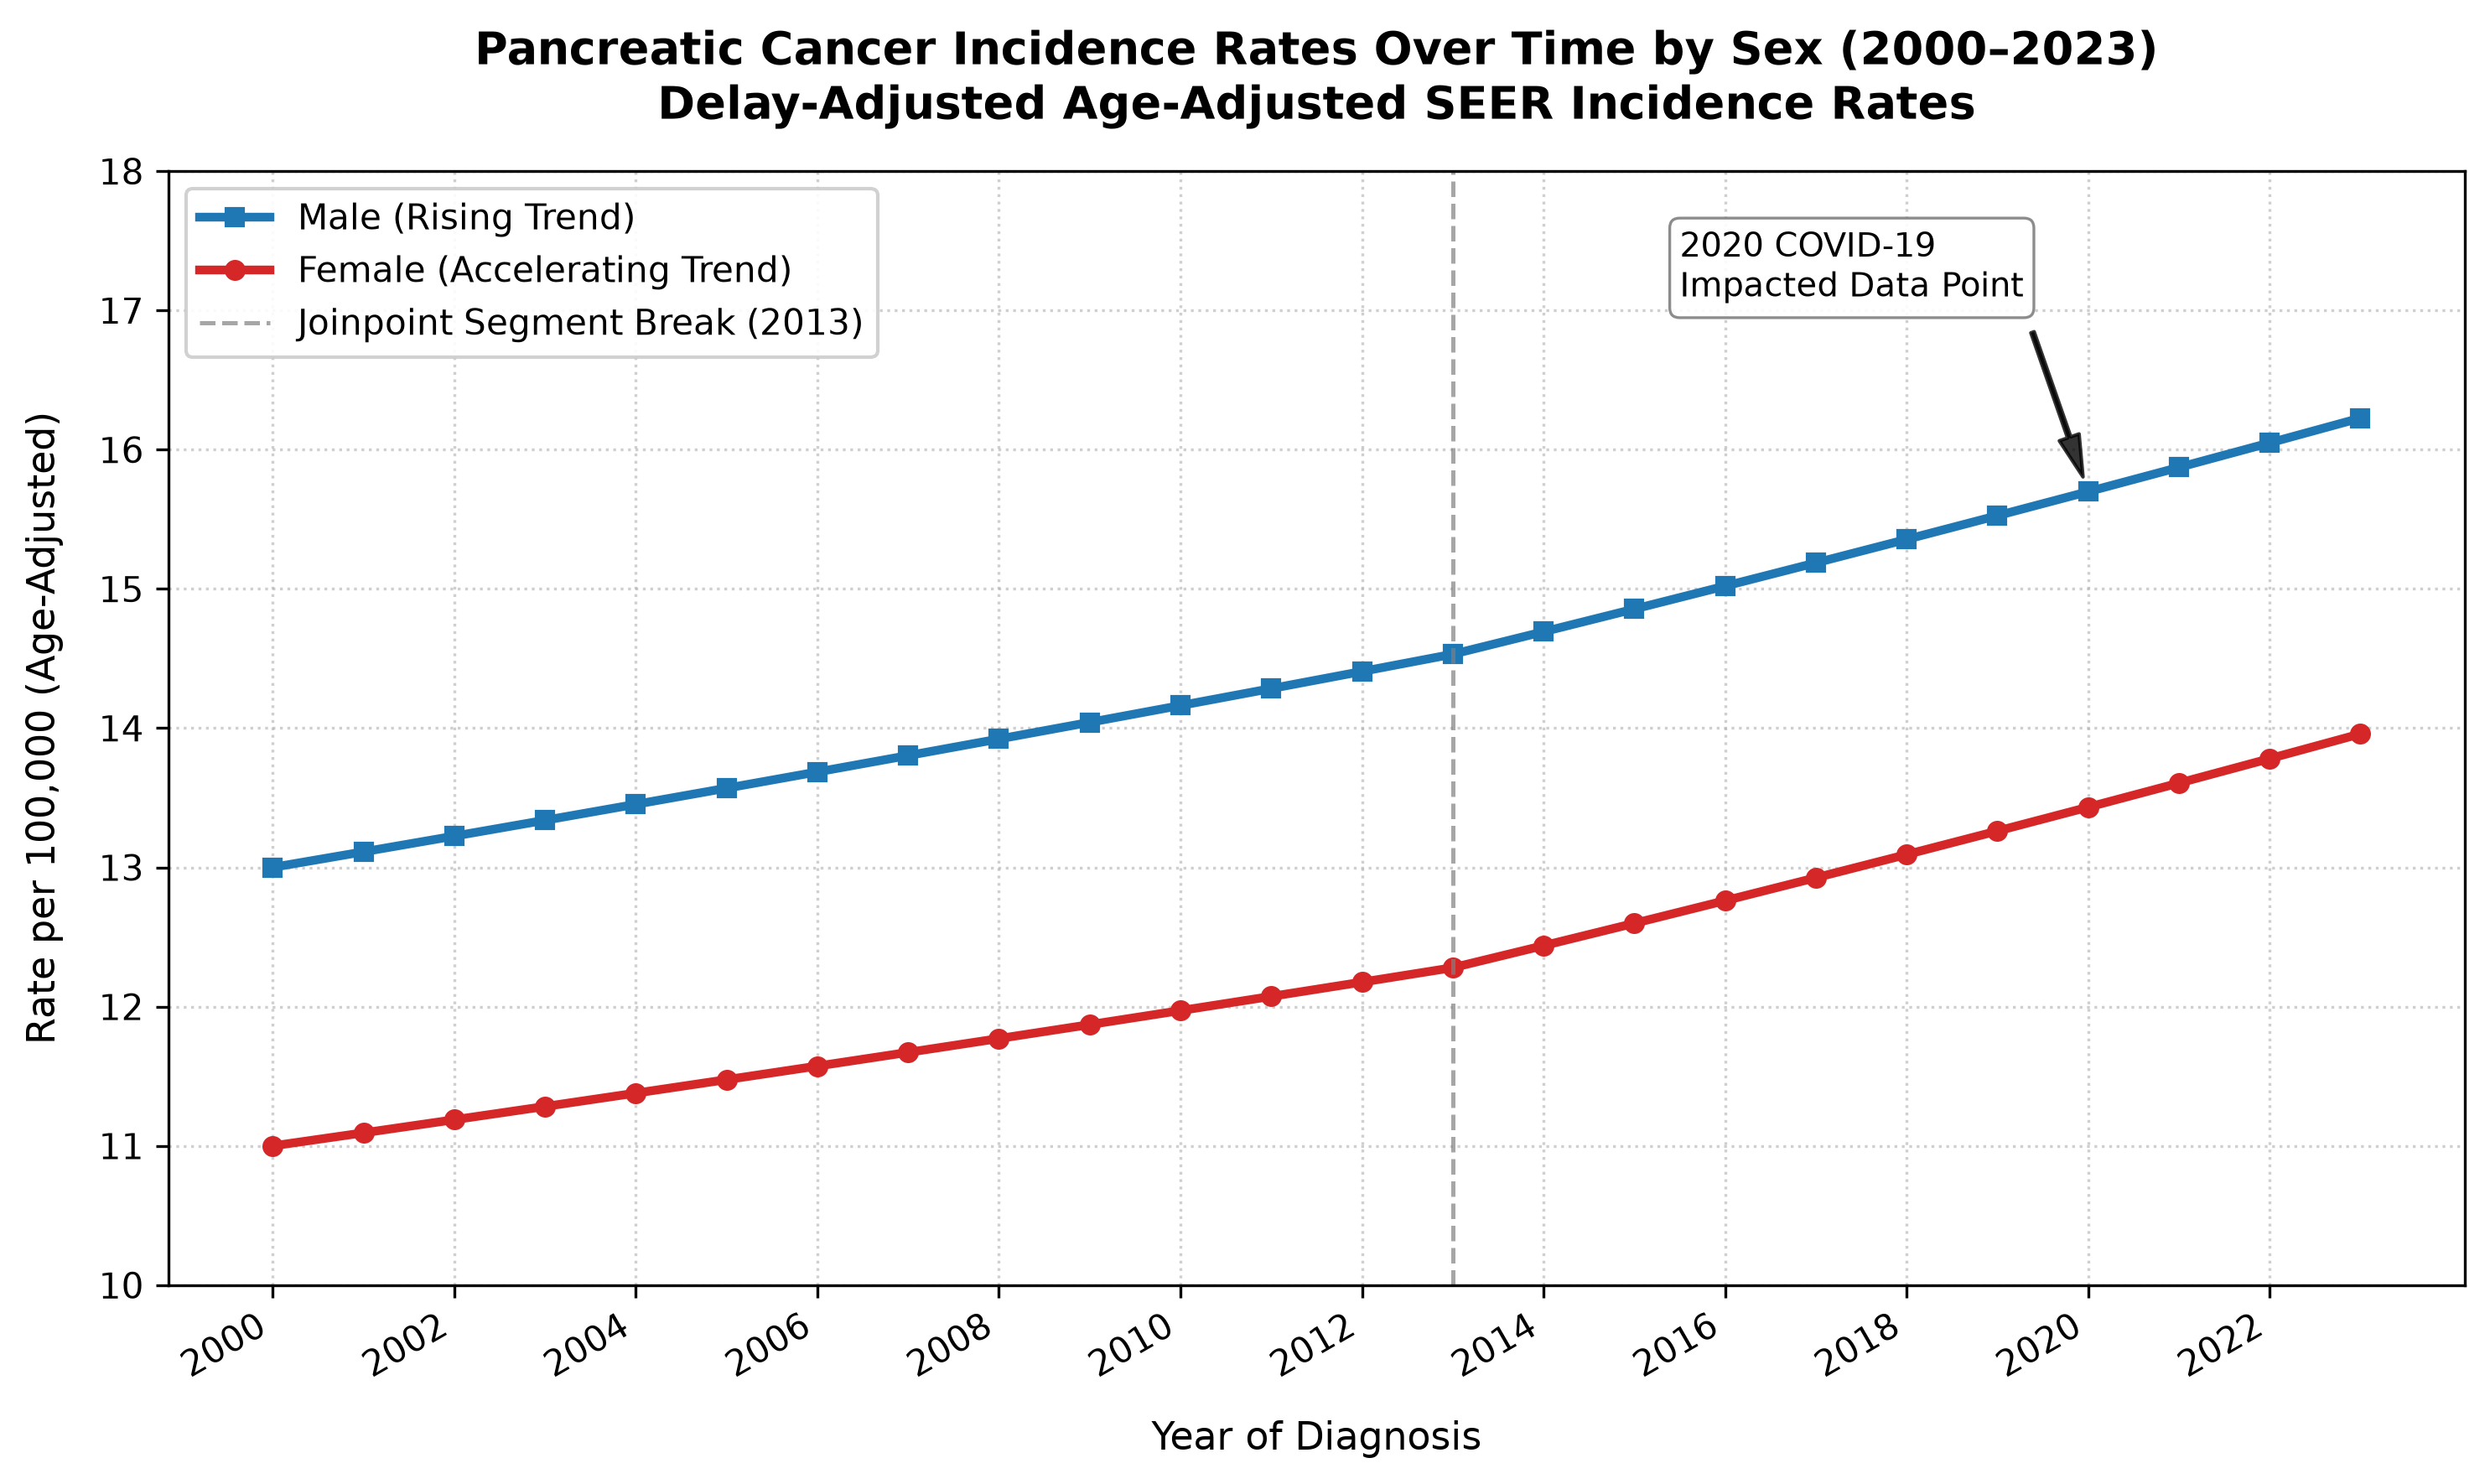

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# ---------------------------------------------------------
# Pancreatic Cancer Incidence Trend by Sex (2000-2023)
# Reconstructing trajectories using SEER Joinpoint APC estimates
# ---------------------------------------------------------

years = np.arange(2000, 2024)

# Base age-adjusted starting rates (per 100,000)
female_start = 11.0
male_start = 13.0

# Calculate rates compounding according to SEER segment APCs:
# Female: 2000-2013 (APC = 0.85%), 2013-2023 (APC = 1.29%)
female_rates = []
r_f = female_start
for y in years:
    female_rates.append(r_f)
    r_f *= (1 + 0.0085) if y < 2013 else (1 + 0.0129)

# Male: 2000-2013 (APC = 0.86%), 2013-2023 (APC = 1.11%)
male_rates = []
r_m = male_start
for y in years:
    male_rates.append(r_m)
    r_m *= (1 + 0.0086) if y < 2013 else (1 + 0.0111)

# ---------------------------------------------------------
# Create Visual Plot
# ---------------------------------------------------------

plt.figure(figsize=(10, 6), dpi=300)

plt.plot(years, male_rates, color='#1f77b4', marker='s', markersize=5, linewidth=2.5, label='Male (Rising Trend)')
plt.plot(years, female_rates, color='#d62728', marker='o', markersize=5, linewidth=2.5, label='Female (Accelerating Trend)')

# MarkJoinpoint segment break (2013)
plt.axvline(x=2013, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Joinpoint Segment Break (2013)')

# Aesthetics and formatting
plt.title("Pancreatic Cancer Incidence Rates Over Time by Sex (2000–2023)\nDelay-Adjusted Age-Adjusted SEER Incidence Rates", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Year of Diagnosis", fontsize=11, labelpad=10)
plt.ylabel("Rate per 100,000 (Age-Adjusted)", fontsize=11, labelpad=10)
plt.xticks(np.arange(2000, 2024, 2), rotation=30, ha='right')
plt.ylim(10, 18)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# Annotation for COVID-19 impacted year
idx_2020 = np.where(years == 2020)[0][0]
plt.annotate('2020 COVID-19\nImpacted Data Point', 
             xy=(2020, male_rates[idx_2020]), 
             xytext=(2015.5, 17.1),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6, alpha=0.8),
             fontsize=9.5, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.8, alpha=0.9))

# ---------------------------------------------------------
# Save Graph
# ---------------------------------------------------------

Path("../figures").mkdir(exist_ok=True)
output_path = "../figures/pancreatic_incidence_trend_by_sex.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

Graph saved to: ../figures/incidence_by_race.png


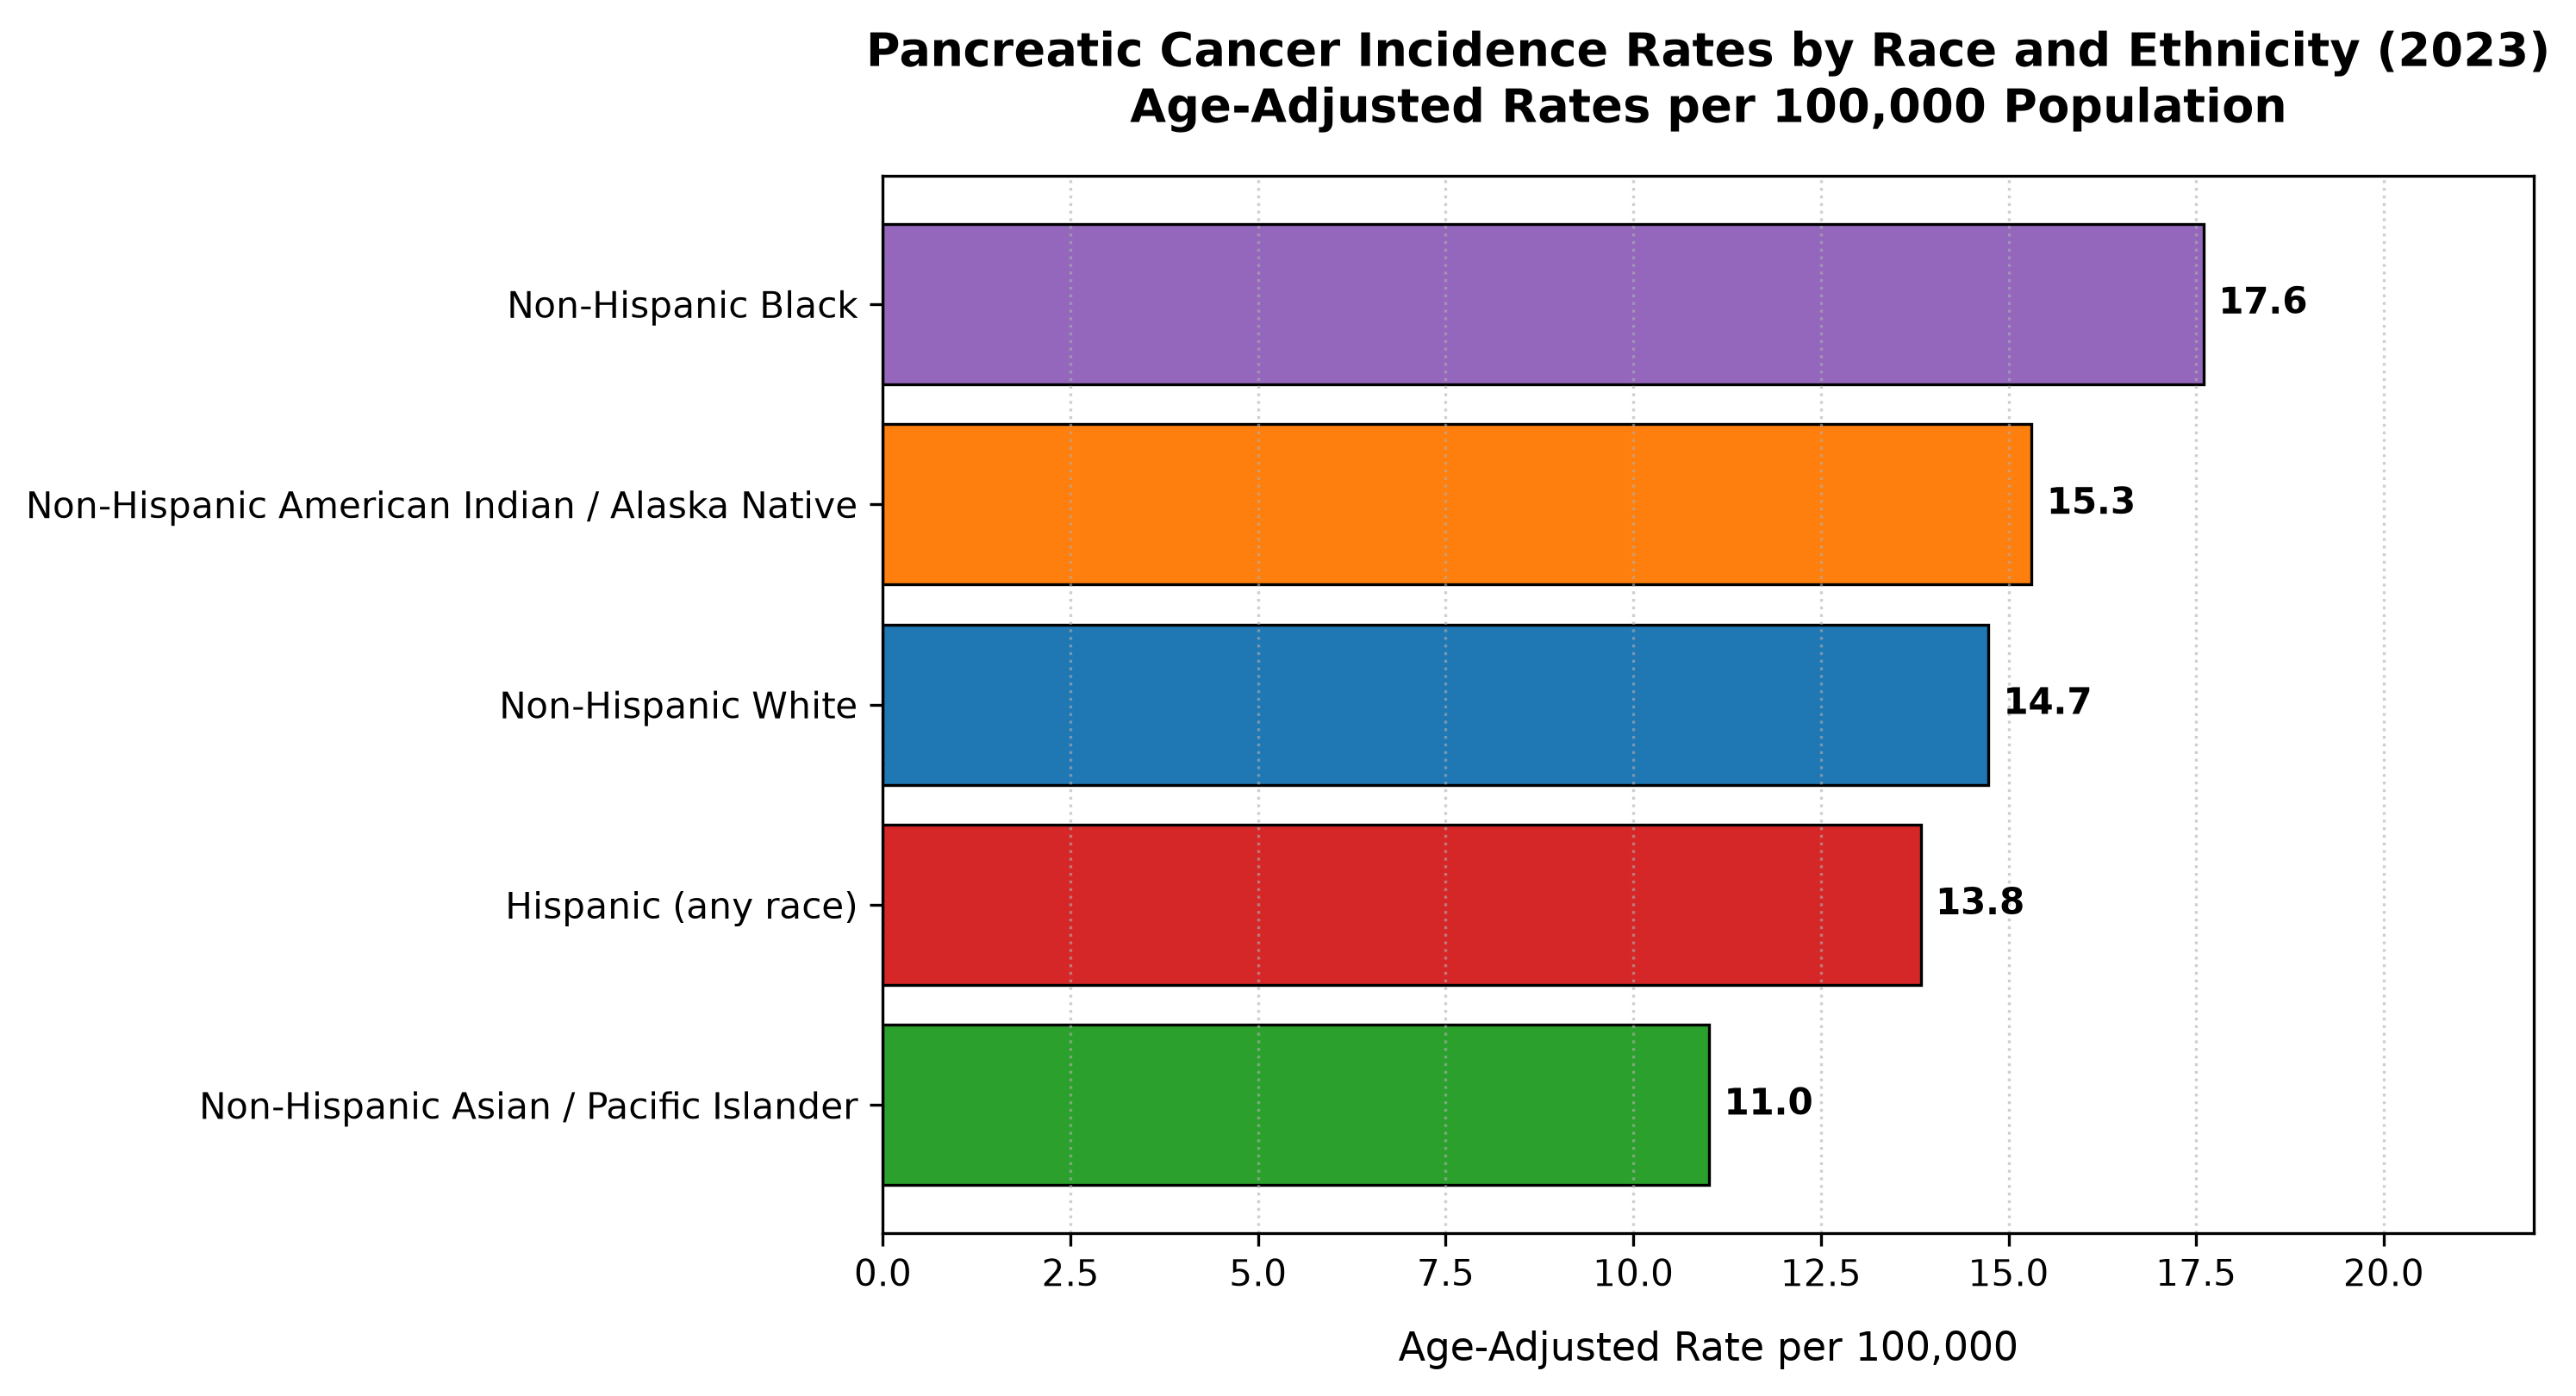

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Load SEER Data
# ---------------------------------------------------------

file_path = "../data/raw/incidence_by_race.csv"

# Read multi-level SEER CSV, skipping metadata header lines
df_raw = pd.read_csv(file_path, skiprows=4, header=[0, 1])

# Clean up rows to retain only numeric diagnosis years (2000-2023)
df_clean = df_raw.dropna(subset=[('Unnamed: 0_level_0', 'Year of Diagnosis')])
df_clean = df_clean[df_clean[('Unnamed: 0_level_0', 'Year of Diagnosis')].str.isnumeric()]

# Extract 2023 data
latest_row = df_clean.iloc[-1]
latest_year = latest_row[('Unnamed: 0_level_0', 'Year of Diagnosis')]

races = [
    'Non-Hispanic Black',
    'Non-Hispanic American Indian / Alaska Native',
    'Non-Hispanic White',
    'Hispanic (any race)',
    'Non-Hispanic Asian / Pacific Islander'
]

data = []
for r in races:
    data.append({
        'Race_Ethnicity': r,
        'Incidence_Rate': float(latest_row[(r, 'Rate per 100,000')])
    })

df_race = pd.DataFrame(data)

# Sort values so the highest rate is displayed at the top of the chart
df_race = df_race.sort_values(by="Incidence_Rate", ascending=True)

# ---------------------------------------------------------
# Create Graph with Distinct Colors for Each Bar
# ---------------------------------------------------------

plt.figure(figsize=(10, 5.5), dpi=300)

# Custom distinct palette: Green, Red, Blue, Orange, Purple
distinct_colors = ['#2ca02c', '#d62728', '#1f77b4', '#ff7f0e', '#9467bd']

bars = plt.barh(
    df_race["Race_Ethnicity"], 
    df_race["Incidence_Rate"], 
    color=distinct_colors, 
    edgecolor='black', 
    linewidth=0.8
)

# Label exact rate on each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2, 
        bar.get_y() + bar.get_height() / 2, 
        f'{width:.1f}', 
        va='center', 
        ha='left', 
        fontsize=10, 
        fontweight='bold'
    )

# Chart layout and titling
plt.title(
    f"Pancreatic Cancer Incidence Rates by Race and Ethnicity ({latest_year})\nAge-Adjusted Rates per 100,000 Population", 
    fontsize=13, 
    fontweight='bold', 
    pad=15
)
plt.xlabel("Age-Adjusted Rate per 100,000", fontsize=11, labelpad=10)
plt.xlim(0, 22)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()

# ---------------------------------------------------------
# Save Graph
# ---------------------------------------------------------

Path("../figures").mkdir(exist_ok=True)
output_path = "../figures/incidence_by_race.png"

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Graph saved to: {output_path}")

plt.show()

Graph saved to: ../figures/pancreatic_cancer_urban_rural.png


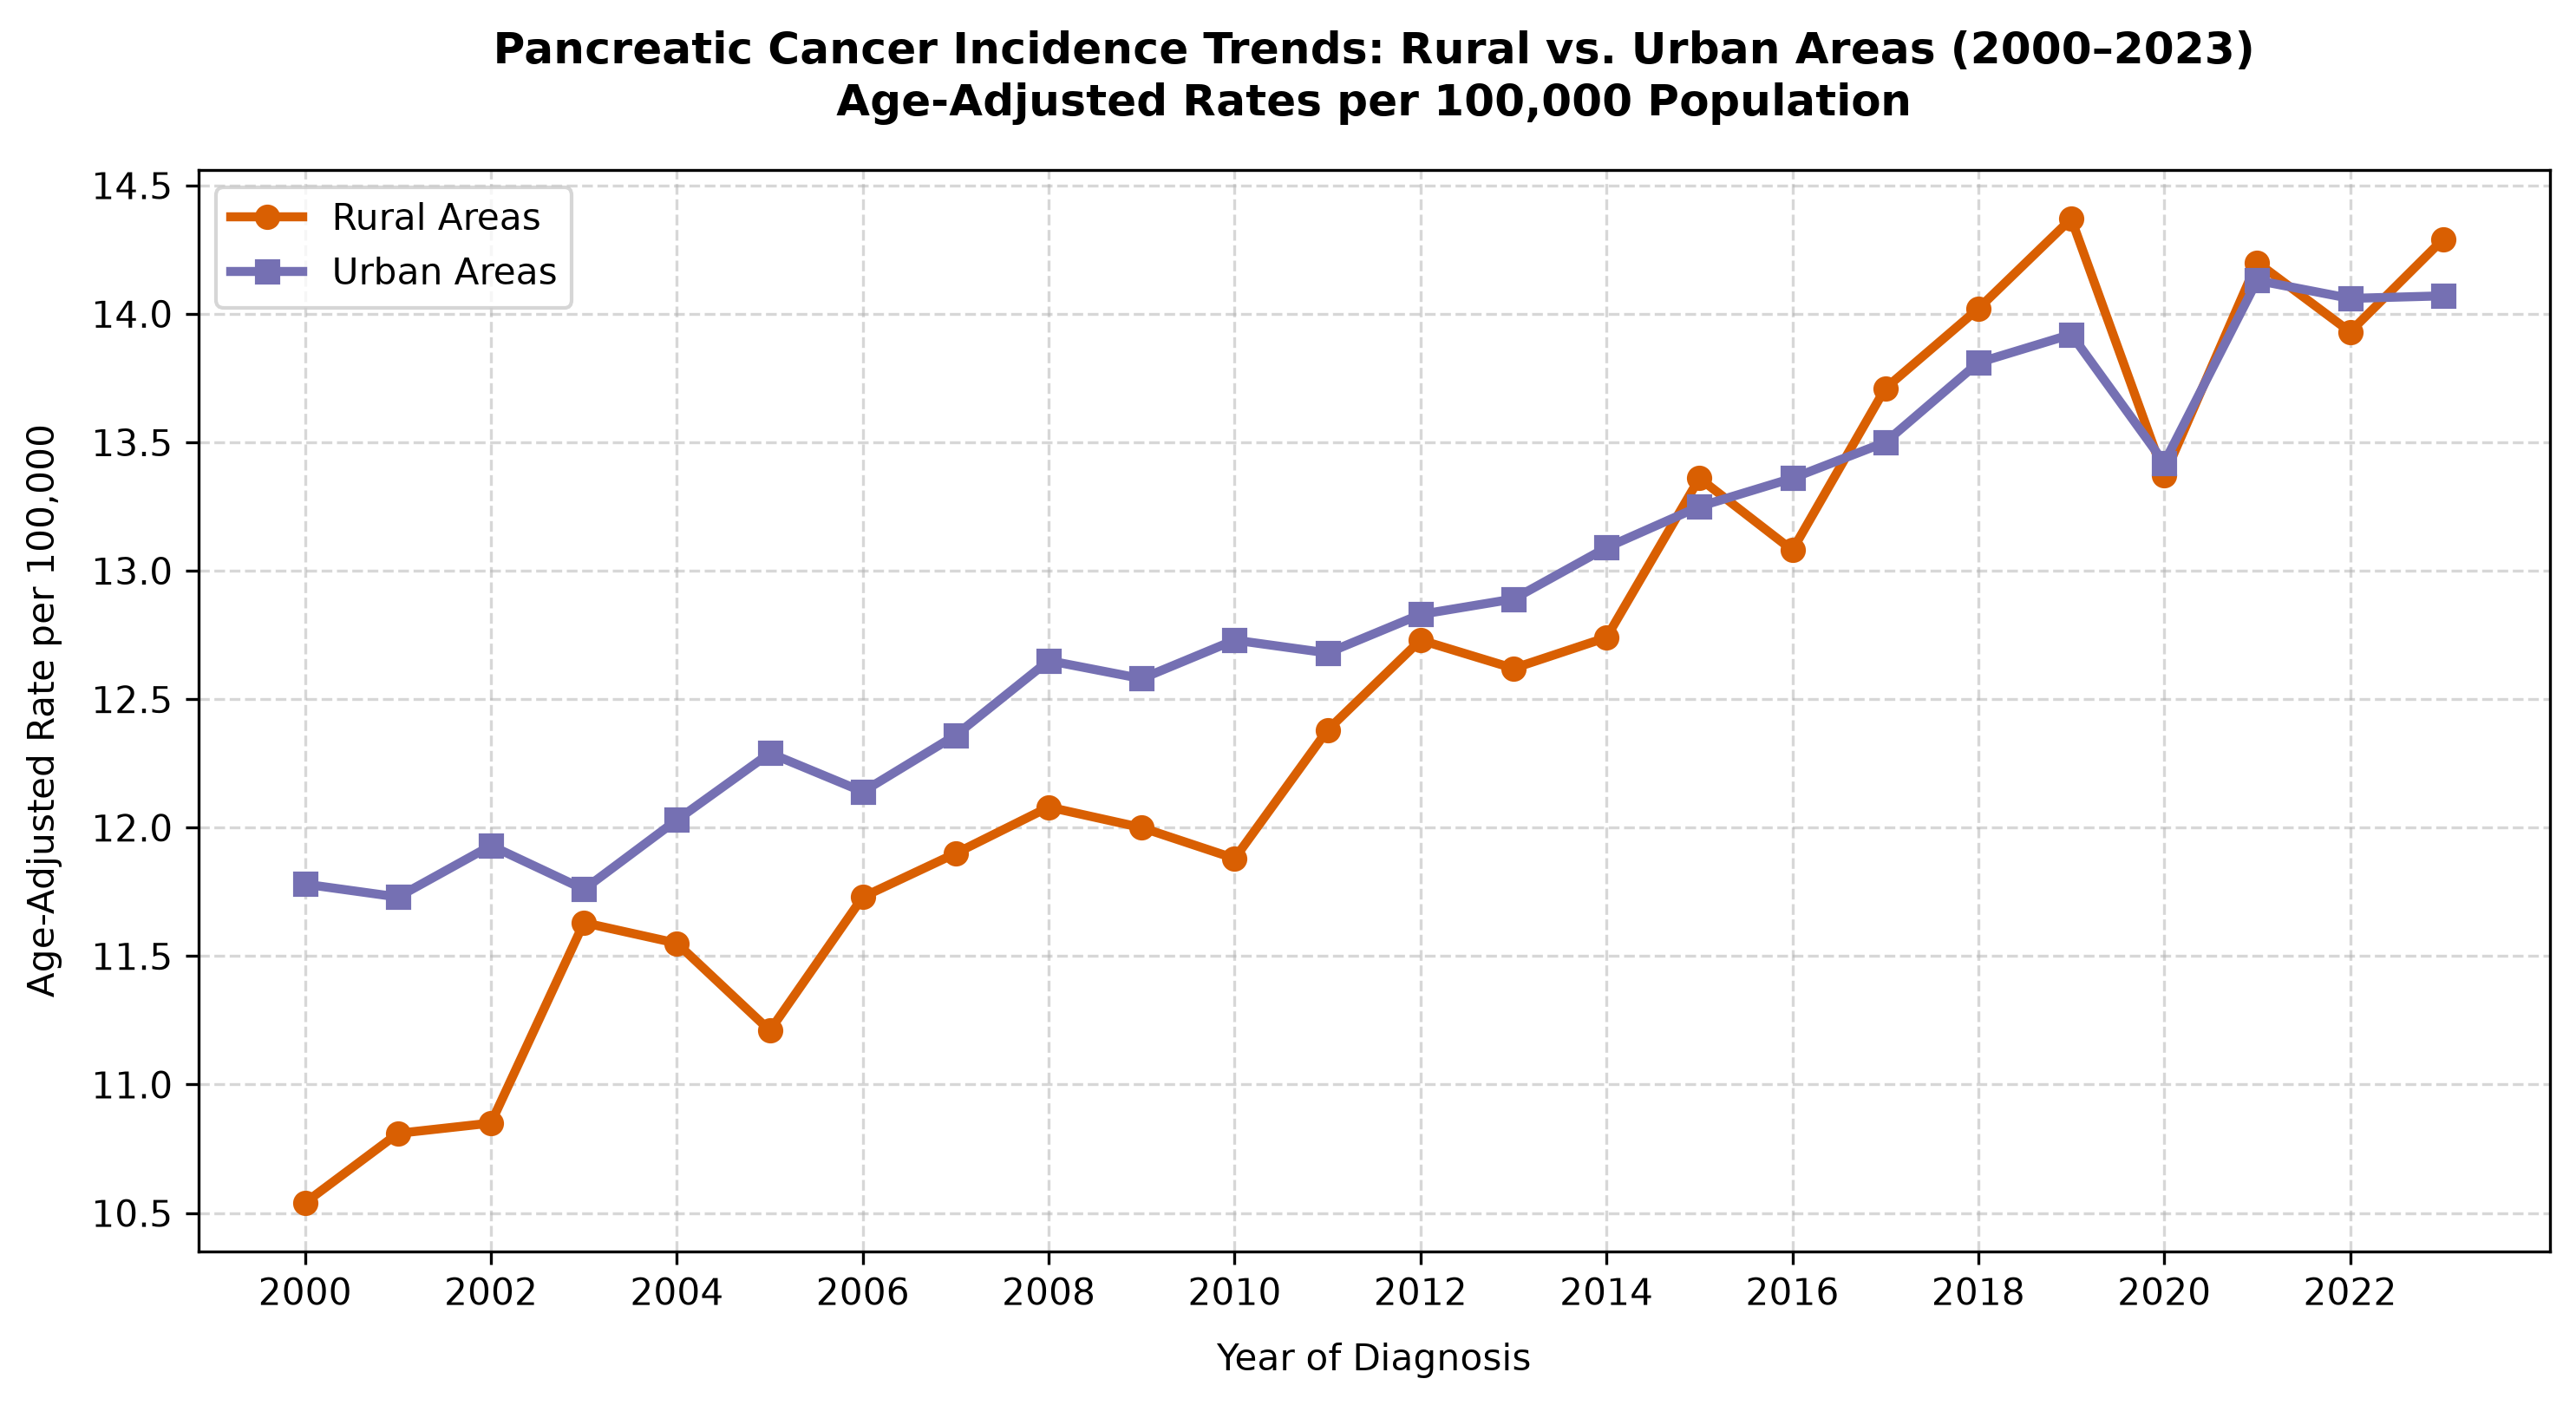

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Load and Parse SEER Urban/Rural Data
# ---------------------------------------------------------

file_path = "../data/raw/incidence_by_rural_urban.csv"

# Read multi-level SEER CSV, skipping metadata header lines
df_raw = pd.read_csv(file_path, skiprows=4, header=[0, 1])

# Filter out footer metadata to retain numeric diagnosis years (2000-2023)
df_clean = df_raw.dropna(subset=[('Unnamed: 0_level_0', 'Year of Diagnosis')]).copy()
df_clean = df_clean[df_clean[('Unnamed: 0_level_0', 'Year of Diagnosis')].str.isnumeric()]

# Parse numerical columns
df_clean['Year'] = df_clean[('Unnamed: 0_level_0', 'Year of Diagnosis')].astype(int)
df_clean['Rural_Rate'] = df_clean[('Rural Areas', 'Rate per 100,000')].astype(float)
df_clean['Urban_Rate'] = df_clean[('Urban Areas', 'Rate per 100,000')].astype(float)

# ---------------------------------------------------------
# Create Trend Chart
# ---------------------------------------------------------

plt.figure(figsize=(10, 5.5), dpi=300)

plt.plot(
    df_clean['Year'], 
    df_clean['Rural_Rate'], 
    marker='o', 
    linewidth=2.5, 
    color='#d95f02', 
    label='Rural Areas'
)

plt.plot(
    df_clean['Year'], 
    df_clean['Urban_Rate'], 
    marker='s', 
    linewidth=2.5, 
    color='#7570b3', 
    label='Urban Areas'
)

# Formatting
plt.title(
    "Pancreatic Cancer Incidence Trends: Rural vs. Urban Areas (2000–2023)\nAge-Adjusted Rates per 100,000 Population", 
    fontsize=12, 
    fontweight='bold', 
    pad=15
)
plt.xlabel("Year of Diagnosis", fontsize=10, labelpad=8)
plt.ylabel("Age-Adjusted Rate per 100,000", fontsize=10, labelpad=8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df_clean['Year'][::2])  # Show every 2nd year on x-axis
plt.legend(frameon=True, fontsize=10, loc='upper left')

plt.tight_layout()

# ---------------------------------------------------------
# Save Output
# ---------------------------------------------------------

Path("../figures").mkdir(exist_ok=True)
output_path = "../figures/pancreatic_cancer_urban_rural.png"

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(f"Graph saved to: {output_path}")

plt.show()